In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
project_path = "/content/drive/MyDrive/Group 7 Capstone Project"
data_path = f"{project_path}/scenicness_dataset_with_pca.csv"

df = pd.read_csv(data_path)
df.head(), df.shape

(   scenicness  connectivity  \
 0           0             0   
 1           0             0   
 2           6             2   
 3           0             0   
 4           3             6   
 
                                              objects  \
 0          ['text (Sorry, we have no imagery here)']   
 1        ["text: 'Sorry, we have no imagery here.'"]   
 2  ['trees', 'fallen branches', 'leaf litter', 'f...   
 3        ["text: 'Sorry, we have no imagery here.'"]   
 4  ['houses', 'cars', 'trash bins', 'power lines'...   
 
                                          description    id   latitude  \
 0  A blank image with a central message stating t...  5513  38.865521   
 1  A blank, featureless screen with a message sta...  3274  38.939376   
 2  A forest scene with dense trees, leaf-covered ...  8371  38.879924   
 3  This image displays a blank background with a ...  3500  38.935775   
 4  A residential street lined with brick row hous...  1912  38.950170   
 
    longitude   

In [4]:
#Define target and feature matrix
target_col = "scenicness"

segmentation_cols = [
    "greenery_pct",
    "building_pct",
    "sky_pct",
    "road_pct",
    "water_pct"
]

pca_cols = [c for c in df.columns if c.startswith("pc_")]

feature_cols = segmentation_cols + pca_cols

X = df[feature_cols].values
y = df[target_col].values

X.shape, y.shape

((997, 55), (997,))

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((797, 55), (200, 55))

**Scale features (required for linear models)**

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#CROSS‑VALIDATION for Lasso
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso

cv_lasso = Lasso(alpha=0.001, max_iter=10000)

scores = cross_val_score(
    cv_lasso,
    X_train_scaled,
    y_train,
    scoring="r2",
    cv=5
)

print("CV R2 scores:", scores)
print("Mean CV R2:", scores.mean())
print("Std CV R2:", scores.std())

CV R2 scores: [0.92730628 0.9175694  0.90754119 0.88597098 0.90539855]
Mean CV R2: 0.9087572824516219
Std CV R2: 0.013810823579265285


In [8]:
#Model Definition
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
}

In [9]:
#Training and evaluating all models
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

results = []

for name, model in models.items():
    if name in ["LinearRegression", "Ridge", "Lasso"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "rmse": rmse,
        "r2": r2
    })

results_df = pd.DataFrame(results)
results_df

,model,rmse,r2
0,LinearRegression,0.731145,0.910107
1,Ridge,0.731198,0.910094
2,Lasso,0.729295,0.910561
3,RandomForest,0.848075,0.879055


In [10]:
# Baseline model (mean predictor)
baseline_pred = np.mean(y_train)
baseline_preds = np.full_like(y_test, baseline_pred)

baseline_rmse = mean_squared_error(y_test, baseline_preds) ** 0.5
baseline_r2 = r2_score(y_test, baseline_preds)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

Baseline RMSE: 2.5874698065871224
Baseline R2: -0.12582029755623836


Lasso is the best model

In [11]:
#Refitting Lasso on the full dataset
best_model = Lasso(alpha=0.001, max_iter=10000, random_state=42)
best_model.fit(X_train_scaled, y_train)

Lasso(alpha=0.001, max_iter=10000, random_state=42)

In [12]:
# Key interpretability step to extract coefficients
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": best_model.coef_
}).sort_values("coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient
5,pc_1,1.669785
0,greenery_pct,0.453955
19,pc_15,0.385601
3,road_pct,0.349022
31,pc_27,0.146384
36,pc_32,0.114776
23,pc_19,0.113334
17,pc_13,0.098549
9,pc_5,0.088648
37,pc_33,0.082553


In [13]:
#Bottom 20 Coefficients
coef_df.tail(20)


,feature,coefficient
26,pc_22,-0.010481
18,pc_14,-0.016146
41,pc_37,-0.019267
21,pc_17,-0.043668
45,pc_41,-0.048037
22,pc_18,-0.051431
51,pc_47,-0.055162
42,pc_38,-0.060042
50,pc_46,-0.061429
12,pc_8,-0.064697


**Segmentation‑only Coefficients**


In [14]:
coef_df[coef_df["feature"].isin(segmentation_cols)]

,feature,coefficient
0,greenery_pct,0.453955
3,road_pct,0.349022
4,water_pct,0.043341
2,sky_pct,-0.000000
1,building_pct,-0.119678


In [19]:
# Load CLIP embeddings and PCA components
embeddings = np.load(f"{project_path}/embeddings/clip_embeddings.npy")
pcs = np.load(f"{project_path}/embeddings/clip_pca_50.npy")

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Segmentation-only (train/test consistent)
X_seg = df[["greenery_pct", "road_pct", "water_pct", "sky_pct", "building_pct"]]
y = df["scenicness"]

X_seg_train, X_seg_test, y_seg_train, y_seg_test = train_test_split(
    X_seg, y, test_size=0.2, random_state=42
)

model_seg = Lasso(alpha=0.001, max_iter=10000).fit(X_seg_train, y_seg_train)
pred_seg = model_seg.predict(X_seg_test)

rmse_seg = mean_squared_error(y_seg_test, pred_seg) ** 0.5
r2_seg = r2_score(y_seg_test, pred_seg)

rmse_seg, r2_seg

(1.0689071611006298, 0.8078685473971678)

In [30]:
# CLIP-only (train/test consistent)
embeddings = np.load(f"{project_path}/embeddings/clip_embeddings.npy")

X_clip = embeddings
y = df["scenicness"]

X_clip_train, X_clip_test, y_clip_train, y_clip_test = train_test_split(
    X_clip, y, test_size=0.2, random_state=42
)

model_clip = Lasso(alpha=0.001, max_iter=10000).fit(X_clip_train, y_clip_train)
pred_clip = model_clip.predict(X_clip_test)

rmse_clip = mean_squared_error(y_clip_test, pred_clip) ** 0.5
r2_clip = r2_score(y_clip_test, pred_clip)

rmse_clip, r2_clip

(0.7581276385834543, 0.9033496975898743)

In [28]:
# PCA-only (train/test consistent)
pcs = np.load(f"{project_path}/embeddings/clip_pca_50.npy")

X_pca = pcs
y = df["scenicness"]

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model_pca = Lasso(alpha=0.001, max_iter=10000).fit(X_pca_train, y_pca_train)
pred_pca = model_pca.predict(X_pca_test)

rmse_pca = mean_squared_error(y_pca_test, pred_pca) ** 0.5
r2_pca = r2_score(y_pca_test, pred_pca)

rmse_pca, r2_pca

(0.744721673908891, 0.9067376255989075)

In [29]:
# Combined model (train/test consistent)
X_combined = np.concatenate([pcs, X_seg], axis=1)
y = df["scenicness"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

model_combined = Lasso(alpha=0.001, max_iter=10000).fit(Xc_train, yc_train)
pred_combined = model_combined.predict(Xc_test)

rmse_combined = mean_squared_error(yc_test, pred_combined) ** 0.5
r2_combined = r2_score(yc_test, pred_combined)

rmse_combined, r2_combined

(0.7255572476808809, 0.9114758302336552)

**Visualization**

**a. Lasso Coefficients (Top 20)**

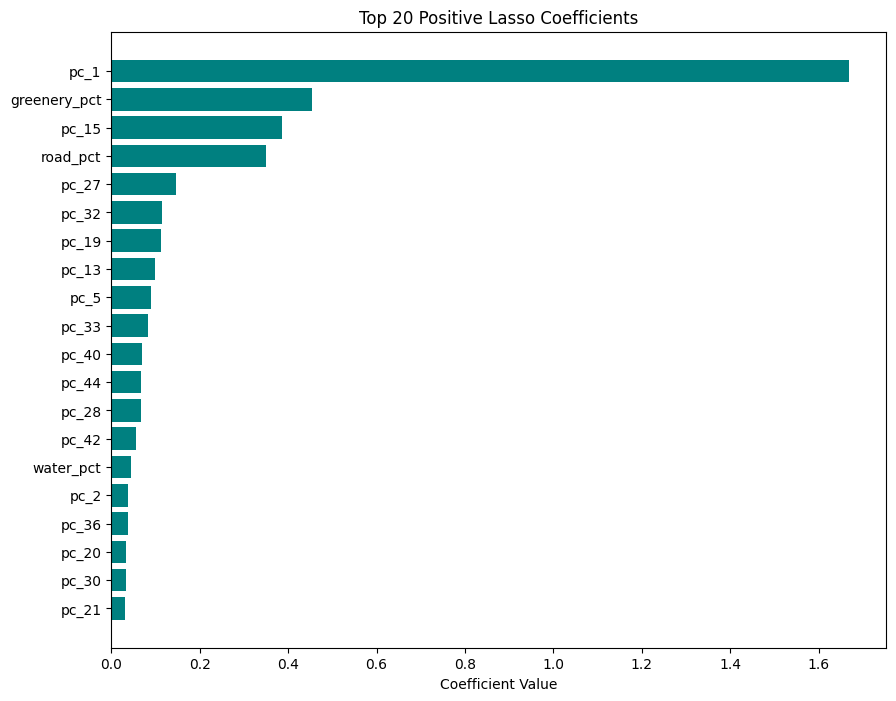

In [ ]:
import matplotlib.pyplot as plt

top20 = coef_df.sort_values("coefficient", ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20["feature"], top20["coefficient"], color="teal")
plt.gca().invert_yaxis()
plt.title("Top 20 Positive Lasso Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

**Top 20 Negative Lasso Coefficients**

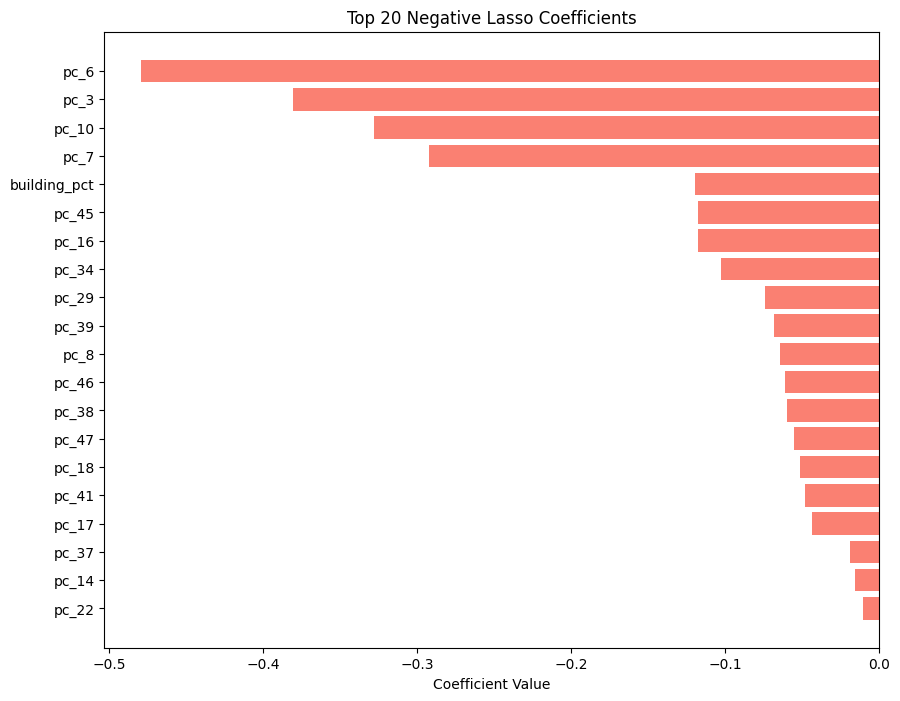

In [ ]:
bottom20 = coef_df.sort_values("coefficient").head(20)

plt.figure(figsize=(10, 8))
plt.barh(bottom20["feature"], bottom20["coefficient"], color="salmon")
plt.gca().invert_yaxis()
plt.title("Top 20 Negative Lasso Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

**Adding Predicted Scenicness to DataFrame**

In [ ]:
df["predicted_scenicness"] = best_model.predict(
    scaler.transform(df[feature_cols])
)

df[["scenicness", "predicted_scenicness"]].head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,scenicness,predicted_scenicness
0,0,0.004501
1,0,0.004428
2,6,5.878412
3,0,0.004444
4,3,3.260773


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

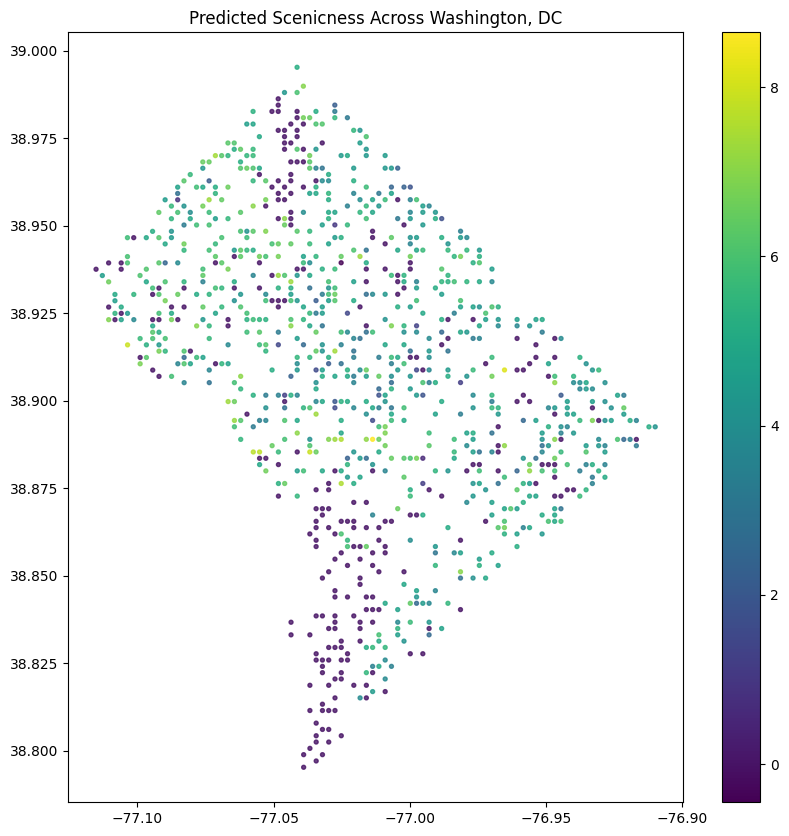

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column="predicted_scenicness",
    cmap="viridis",
    markersize=8,
    legend=True,
    alpha=0.8
)

ax.set_title("Predicted Scenicness Across Washington, DC")
plt.show()

**The Census Tract Choropleth**

In [ ]:
import os

folder = "/content/drive/MyDrive/Group 7 Capstone Project"
os.listdir(folder)

['DC_images',
 'scenicness_dataset.csv',
 'embeddings',
 'Notebook 01: Extract Embeddings.ipynb',
 'scenicness_dataset_with_pca.csv',
 'Notebook 02_PCA_Embeddings.ipynb',
 'Notebook 03: Regression Modeling.ipynb']

In [ ]:
!wget -O dc_tracts.zip "https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_11_tract.zip"
!unzip -o dc_tracts.zip -d dc_tracts

--2026-04-11 00:16:14--  https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_11_tract.zip
Resolving www2.census.gov (www2.census.gov)... 172.65.90.26, 172.65.90.25, 172.65.90.24, ...
Connecting to www2.census.gov (www2.census.gov)|172.65.90.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 361656 (353K) [application/zip]
Saving to: ‘dc_tracts.zip’

dc_tracts.zip       100%[===================>] 353.18K  --.-KB/s    in 0.04s   

2026-04-11 00:16:14 (9.80 MB/s) - ‘dc_tracts.zip’ saved [361656/361656]

Archive:  dc_tracts.zip
 extracting: dc_tracts/tl_2020_11_tract.cpg  
  inflating: dc_tracts/tl_2020_11_tract.dbf  
  inflating: dc_tracts/tl_2020_11_tract.prj  
  inflating: dc_tracts/tl_2020_11_tract.shp  
  inflating: dc_tracts/tl_2020_11_tract.shp.ea.iso.xml  
  inflating: dc_tracts/tl_2020_11_tract.shp.iso.xml  
  inflating: dc_tracts/tl_2020_11_tract.shx  


In [ ]:
tracts = gpd.read_file("dc_tracts/tl_2020_11_tract.shp").to_crs("EPSG:4326")
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,11,001,004001,11001004001,40.01,Census Tract 40.01,G5020,S,271037,2414,+38.9208738,-077.0462674,"POLYGON ((-77.05018 38.92124, -77.05006 38.921..."
1,11,001,004002,11001004002,40.02,Census Tract 40.02,G5020,S,194755,0,+38.9181186,-077.0437209,"POLYGON ((-77.0463 38.91631, -77.0463 38.91637..."
2,11,001,003600,11001003600,36,Census Tract 36,G5020,S,305616,0,+38.9236744,-077.0296273,"POLYGON ((-77.03241 38.92657, -77.03217 38.926..."
3,11,001,004201,11001004201,42.01,Census Tract 42.01,G5020,S,204529,0,+38.9162076,-077.0388456,"POLYGON ((-77.04166 38.91418, -77.04166 38.914..."
4,11,001,004202,11001004202,42.02,Census Tract 42.02,G5020,S,207646,0,+38.9134023,-077.0430254,"POLYGON ((-77.04599 38.9145, -77.04574 38.9146..."


In [ ]:
# Spatial Join (assign each point to a tract)
joined = gpd.sjoin(gdf, tracts, how="left", predicate="within")

In [ ]:
#Compute mean scenicness per tract
tract_means = (
    joined.groupby("GEOID")["predicted_scenicness"]
    .mean()
    .reset_index()
)

tract_means.rename(
    columns={"predicted_scenicness": "mean_predicted_scenicness"},
    inplace=True
)

In [ ]:
#Merge with the tract polygons
tracts_merged = tracts.merge(tract_means, on="GEOID", how="left")

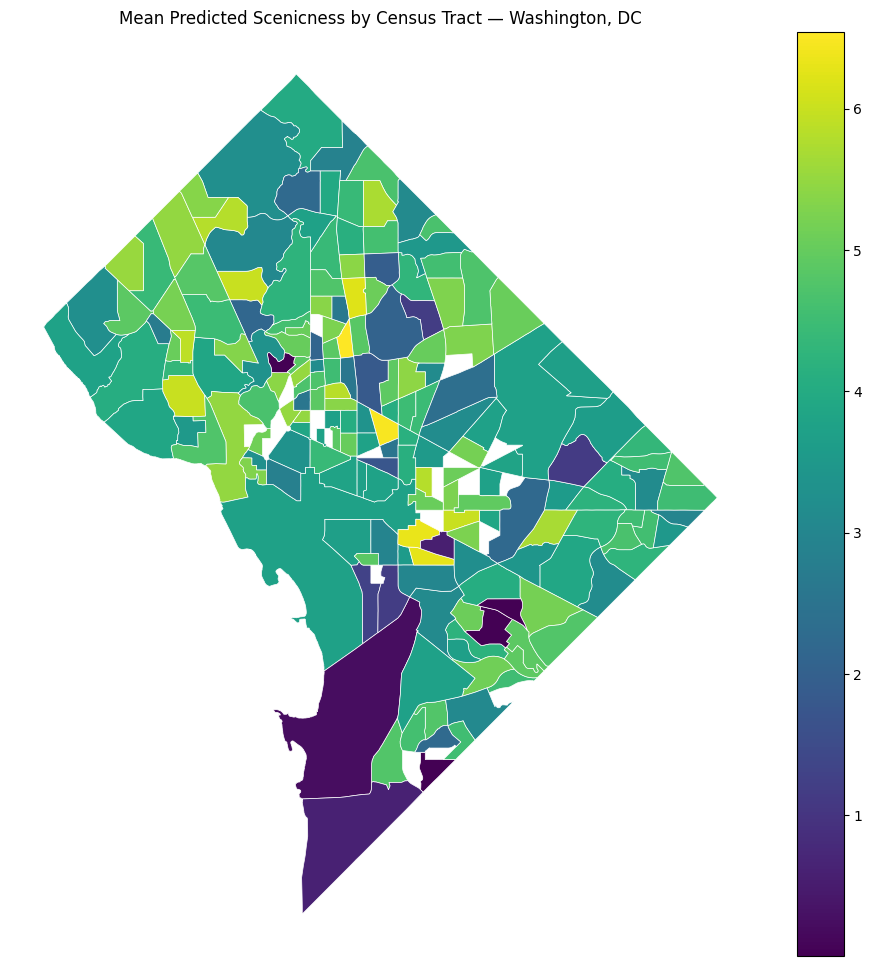

In [ ]:
#choropleth Map
fig, ax = plt.subplots(figsize=(12, 12))

tracts_merged.plot(
    ax=ax,
    column="mean_predicted_scenicness",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

ax.set_title("Mean Predicted Scenicness by Census Tract — Washington, DC")
ax.axis("off")
plt.show()

**Residuals Across DC (Over/Under-Prediction Map)**

In [ ]:
#Residuals Compute
df["residual"] = df["scenicness"] - df["predicted_scenicness"]
#Positive residual - model under‑predicted
#Negative residual - model over‑predicted


In [ ]:
#Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

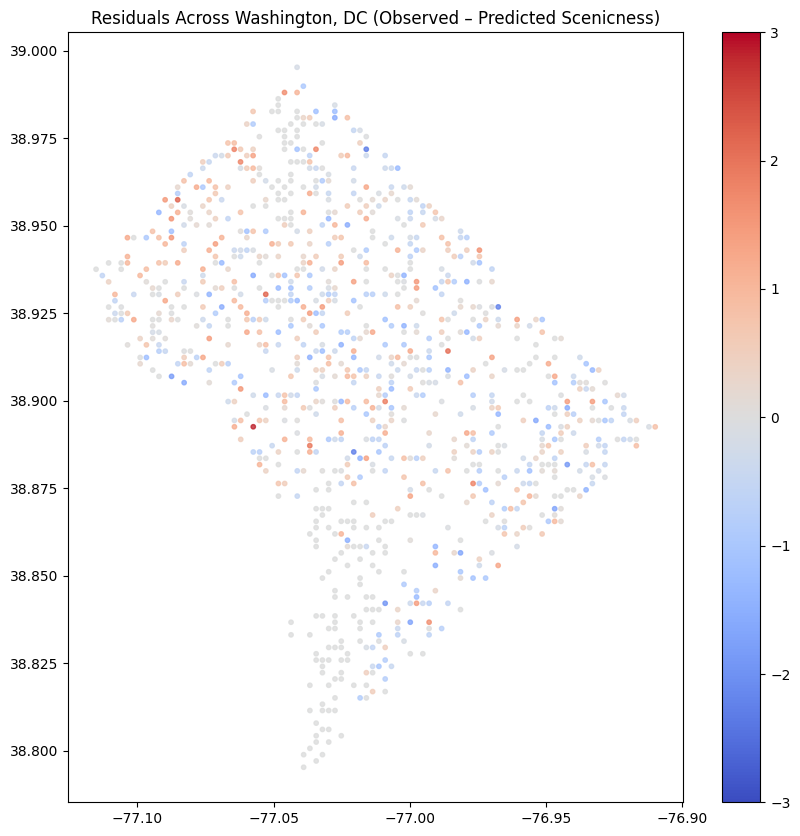

In [ ]:
#Residual Plot
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column="residual",
    cmap="coolwarm",
    markersize=10,
    legend=True,
    vmin=-3,
    vmax=3,
    alpha=0.8
)

ax.set_title("Residuals Across Washington, DC (Observed – Predicted Scenicness)")
plt.show()

**Smoothed Scenicness Surface (KDE Heatmap)**

In [ ]:
# Extract coordinates & predicted scenicness values
import numpy as np

coords = np.vstack([gdf.geometry.x, gdf.geometry.y])

values = gdf["predicted_scenicness"].values
values = values - values.min() + 1e-6

In [ ]:
#Fit a weighted KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(coords, weights=values, bw_method=0.05)

In [ ]:
#Grid over DC
xmin, ymin, xmax, ymax = gdf.total_bounds

xx, yy = np.mgrid[xmin:xmax:300j, ymin:ymax:300j]
grid_coords = np.vstack([xx.ravel(), yy.ravel()])

In [ ]:
#Evaluate KDE on the grid
zz = kde(grid_coords).reshape(xx.shape)

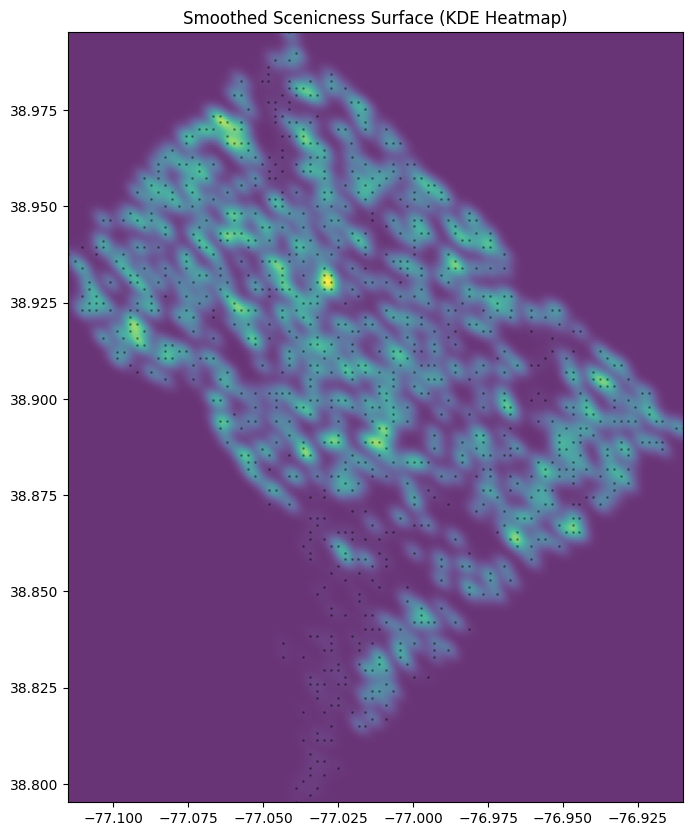

In [ ]:
#Smoothed Scenicness Heatmap
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    np.rot90(zz),
    cmap="viridis",
    extent=[xmin, xmax, ymin, ymax],
    alpha=0.8
)

gdf.plot(ax=ax, markersize=1, color="black", alpha=0.3)

ax.set_title("Smoothed Scenicness Surface (KDE Heatmap)")
plt.show()